In [ ]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Problem statement overview - This project focuses on building a machine learning model to automatically classify comments based on their content and associated metadata. It combines text vectorization, feature engineering, and multiple models to improve classification performance.

Linear SVC

In the first step I have written all libraries which needs to be imported 

In [1]:
import pandas as pd
import numpy as np
import pickle
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

I have loaded the training data and test data 

In [2]:
train_data = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_data = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

print(train_data.shape, test_data.shape)

(198000, 15) (102000, 14)


EDA - EXPLORATORY DATA ANALYSIS 

In [3]:
print(train_data.shape)
print(train_data.info())
print(train_data.isnull().sum())
train_data.head()

(198000, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB
None
created_date         0
post_id              0
emoticon_1           0
emoticon_2 

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


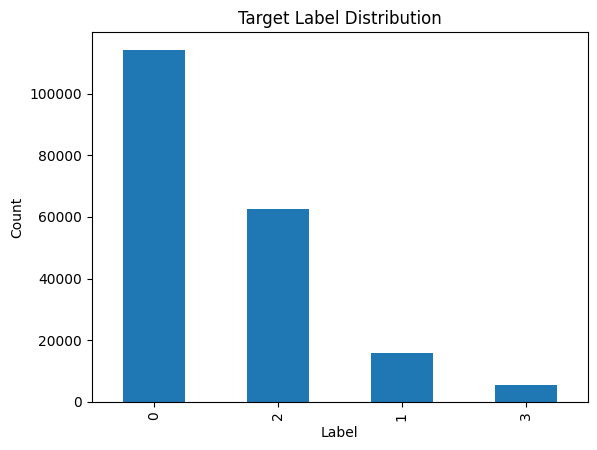

In [4]:
import matplotlib.pyplot as plt
train_data["label"].value_counts().plot(kind="bar")
plt.title("Target Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [19]:
num_cols_original = ["upvote","downvote", "if_1", "if_2", "emoticon_1","emoticon_2","emoticon_3"]


In [20]:
def detect_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR 
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        print(f"{col}: {len(outliers)} outliers")
        print(f"Lower Bound: {lower}, Upper Bound: {upper}")
        print("-"*40)
detect_outliers_iqr(train_data, num_cols_original)

upvote: 17304 outliers
Lower Bound: -4.5, Upper Bound: 7.5
----------------------------------------
downvote: 15173 outliers
Lower Bound: -1.5, Upper Bound: 2.5
----------------------------------------
if_1: 85 outliers
Lower Bound: -6.0, Upper Bound: 10.0
----------------------------------------
if_2: 3930 outliers
Lower Bound: -5.0, Upper Bound: 19.0
----------------------------------------
emoticon_1: 28922 outliers
Lower Bound: 0.0, Upper Bound: 0.0
----------------------------------------
emoticon_2: 8109 outliers
Lower Bound: 0.0, Upper Bound: 0.0
----------------------------------------
emoticon_3: 17165 outliers
Lower Bound: 0.0, Upper Bound: 0.0
----------------------------------------


This step is data cleaning where I filled the NAN (null) values with ""(empty strings)

In [10]:
train_data["comment"] = train_data["comment"].fillna("")
test_data["comment"] = test_data["comment"].fillna("")
train_data["disability"] = train_data["disability"].astype(int) #I converted the disability column to integer because it is a binary indicator feature, and machine learning models require numerical inputs to learn patterns effectively
test_data["disability"] = test_data["disability"].astype(int)

Feature Engineering - so that models learn patterns better 

In [11]:
for df in [train_data, test_data]:
    df["comment_length"] = df["comment"].str.len()
    df["word_count"] = df["comment"].str.split().str.len()
    df["exclamation_count"] = df["comment"].str.count("!")
    df["question_count"] = df["comment"].str.count(r"\?")
    df["capital_ratio"] = df["comment"].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
    df["total_emoticons"] = ( df["emoticon_1"] + df["emoticon_2"] + df["emoticon_3"])
    df["vote_diff"] = df["upvote"] - df["downvote"]
    df["total_votes"] = df["upvote"] + df["downvote"]

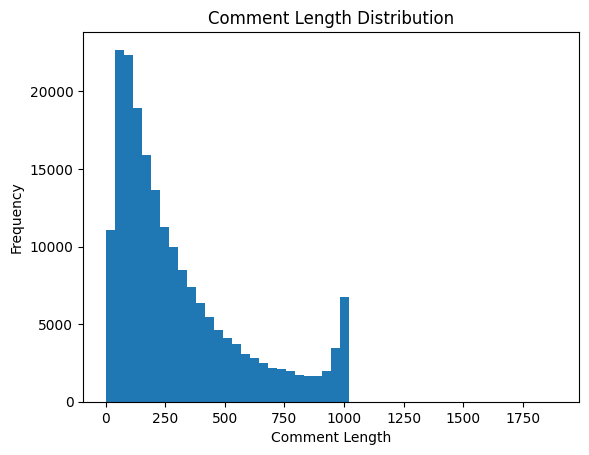

In [6]:
train_data["comment"] = train_data["comment"].fillna("")
train_data["comment_length"] = train_data["comment"].str.len()
plt.hist(train_data["comment_length"], bins=50)
plt.title("Comment Length Distribution")
plt.xlabel("Comment Length")
plt.ylabel("Frequency")
plt.show()

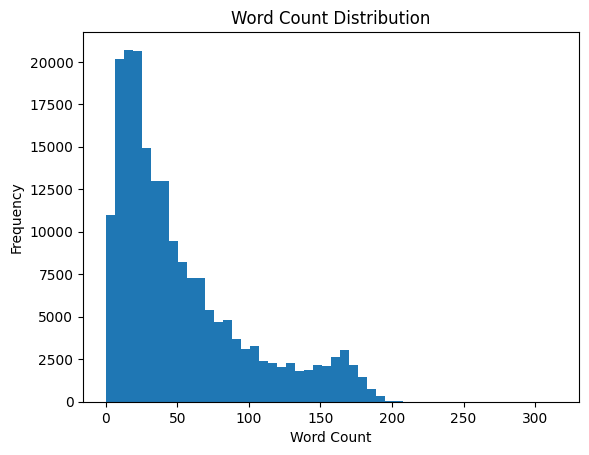

In [8]:
train_data["word_count"] = train_data["comment"].str.split().str.len()
plt.hist(train_data["word_count"], bins=50)
plt.title("Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

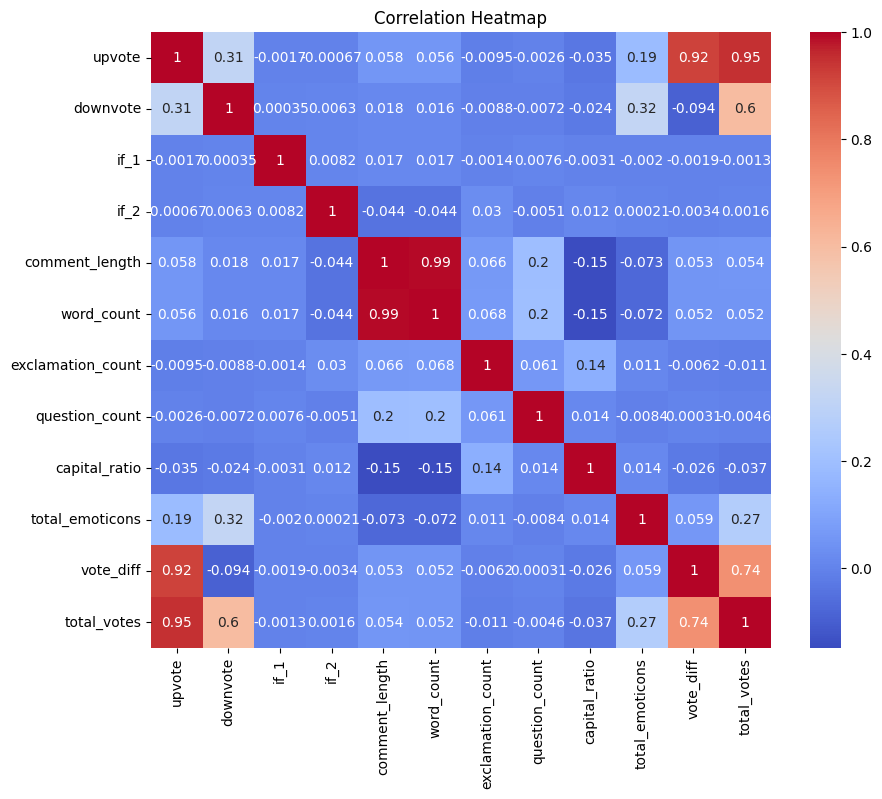

In [9]:
import seaborn as sns
train_data["exclamation_count"] = train_data["comment"].str.count("!")
train_data["question_count"] = train_data["comment"].str.count(r"\?")
train_data["capital_ratio"] = train_data["comment"].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
train_data["total_emoticons"] = (train_data["emoticon_1"] + train_data["emoticon_2"] + train_data["emoticon_3"])
train_data["vote_diff"] = train_data["upvote"] - train_data["downvote"]
train_data["total_votes"] = train_data["upvote"] + train_data["downvote"]
corr_cols = ["upvote", "downvote", "if_1", "if_2", "comment_length", "word_count", "exclamation_count", "question_count","capital_ratio", "total_emoticons", "vote_diff", "total_votes"]
plt.figure(figsize=(10, 8))
sns.heatmap(train_data[corr_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

These are my numerical columns after adding feature engineering part

In [12]:
num_cols = ["upvote", "downvote","if_1", "if_2","emoticon_1", "emoticon_2", "emoticon_3","disability","comment_length","word_count","exclamation_count","question_count","capital_ratio","total_emoticons","vote_diff","total_votes"]


I splitted the data into train data and test data

In [13]:
X = train_data
y = train_data['label']
X_train,X_val,y_train,y_val = train_test_split(X,y,test_size = 0.2,stratify = y,random_state = 42)

TF-IDF converts text into numerical vectors by weighting words based on frequency and importance, and using both word-level and character-level representations helps capture semantic meaning and textual patterns effectively

In [14]:
word_vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1,2))
char_vectorizer = TfidfVectorizer(analyzer="char", ngram_range=(3,5), max_features=15000)
X_train_word = word_vectorizer.fit_transform(X_train["comment"])
X_val_word = word_vectorizer.transform(X_val["comment"])
X_train_char = char_vectorizer.fit_transform(X_train["comment"])
X_val_char = char_vectorizer.transform(X_val["comment"])

Standard Scaler - used for normalisation

In [15]:
scaler = StandardScaler()
X_train_num = csr_matrix(scaler.fit_transform(X_train[num_cols].astype(float)))
X_val_num = csr_matrix(scaler.transform(X_val[num_cols].astype(float)))

hstack-used to stack different kinds of variables 

In [16]:
X_train_final = hstack([X_train_word, X_train_char, X_train_num])
X_val_final = hstack([X_val_word, X_val_char, X_val_num])

In [11]:
svc_model = LinearSVC(random_state=42)
svc_model.fit(X_train_final, y_train)
svc_pred = svc_model.predict(X_val_final)
print("LinearSVC Accuracy:", accuracy_score(y_val, svc_pred))
print("LinearSVC F1:", f1_score(y_val, svc_pred, average="weighted"))
print(classification_report(y_val, svc_pred))

LinearSVC Accuracy: 0.7879292929292929
LinearSVC F1: 0.7830711741108035
              precision    recall  f1-score   support

           0       0.81      0.88      0.84     22835
           1       0.71      0.59      0.65      3183
           2       0.77      0.70      0.73     12488
           3       0.64      0.37      0.47      1094

    accuracy                           0.79     39600
   macro avg       0.73      0.64      0.67     39600
weighted avg       0.78      0.79      0.78     39600



In [12]:
with open("/kaggle/working/linear_svc_model.pkl", "wb") as f:
    pickle.dump(svc_model, f)

Training on full data

In [19]:
X_full_word = word_vectorizer.fit_transform(train_data["comment"])
X_full_char = char_vectorizer.fit_transform(train_data["comment"])
X_full_num = scaler.fit_transform(train_data[num_cols].astype(float))
X_full_num = csr_matrix(X_full_num)
X_full = hstack([X_full_word, X_full_char, X_full_num]).tocsr()
y_full = train_data["label"]
X_test_word = word_vectorizer.transform(test_data["comment"])
X_test_char = char_vectorizer.transform(test_data["comment"])
X_test_num = scaler.transform(test_data[num_cols].astype(float))
X_test_num = csr_matrix(X_test_num)
X_test_final = hstack([X_test_word, X_test_char, X_test_num]).tocsr()

In [ ]:
final_svc_model = LinearSVC(random_state=42)
final_svc_model.fit(X_full, y_full)

In [ ]:
import pickle

with open("/kaggle/working/linear_svc_full_model.pkl", "wb") as f:
    pickle.dump(final_svc_model, f)


In [ ]:
svc_preds = final_svc_model.predict(X_test_final)

submission_svc = pd.DataFrame({
    "ID": range(1, len(svc_preds) + 1),
    "label": svc_preds
})

submission_svc.to_csv("submission_svc.csv", index=False)
submission_svc.head()

LOGISTIC REGRESSION WITH HYPERPARAMETER TUNING 

TfidVectoriser-used for converting text into numerical features. max_features - 50000 means I want to keep top 50000 most important records,ngram_range = (1,2) means Use:Unigrams (1 word),Bigrams (2 words) it is usefule for understanding context,min_df=3 means ignoring words appearing in less than 3 documents(can remove typing mistakes and noise),max_df=0.95 means we ignore words appearing in more than 95% of the documents,sublinear_tf=True is used for count of words on log scale output of tfidf vectorizer is sparse matrix 

In [ ]:
word_vectorizer = TfidfVectorizer(max_features=50000,ngram_range=(1, 2),min_df=3,max_df=0.95,sublinear_tf=True)
X_train_word = word_vectorizer.fit_transform(X_train["comment"])
X_valid_word = word_vectorizer.transform(X_valid["comment"])

char_vectoriser is used for converting text into characters instead of words.The parameters are:- 
analyse = "char",ngram_range = (3,5) for creating character sequences of length 3 and 4,max_fatures = 15000 used for finding most important character patterns.

In [ ]:
char_vectorizer = TfidfVectorizer(analyzer="char", ngram_range=(3, 5), max_features=15000)
X_train_char = char_vectorizer.fit_transform(X_train["comment"])
X_valid_char = char_vectorizer.transform(X_valid["comment"])

Standard Scaler is used for normalisation(converting to float ensures no errors) 
csr_matrix(compresed sparse row) is used for storing sparse data row wise 

In [ ]:
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_cols].astype(float))
X_valid_num = scaler.transform(X_valid[num_cols].astype(float))
X_train_num = csr_matrix(X_train_num)
X_valid_num = csr_matrix(X_valid_num)

In [ ]:
X_train_final = hstack([X_train_word, X_train_char, X_train_num]).tocsr()
X_valid_final = hstack([X_valid_word, X_valid_char, X_valid_num]).tocsr()

In [ ]:
for c in [2.0, 3.0, 4.0]:
    temp_model = LogisticRegression(C=c, max_iter=2500, solver="saga",n_jobs=-1)
    temp_model.fit(X_train_final, y_train)
    temp_preds = temp_model.predict(X_valid_final)
    temp_score = accuracy_score(y_valid, temp_preds)
    print("C =", c, " Validation Accuracy =", temp_score)

In [ ]:
import pickle
# Save vectorizers
with open("/kaggle/working/vectorizer_word.pkl","wb") as f:
    pickle.dump(word_vectorizer,f)
with open("/kaggle/working/vectorizer_char.pkl","wb") as f:
    pickle.dump(char_vectorizer,f)
with open("/kaggle/working/scaler.pkl","wb") as f:
    pickle.dump(scaler,f)

In [ ]:
with open("/kaggle/working/logreg_model.pkl","wb") as f:
    pickle.dump(temp_model, f)

In [ ]:
got c = 2 as best hyperparameter

In [ ]:
saved_path = "/kaggle/input/datasets/psanandha/saved-files"
with open(f"{saved_path}/vectorizer_word.pk", "rb") as f:
    word_vectorizer = pickle.load(f)
with open(f"{saved_path}/vectorizer_char.pkl", "rb") as f:
    char_vectorizer = pickle.load(f)
with open(f"{saved_path}/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

In [ ]:
final_model = LogisticRegression(C=2.0,max_iter=2500,solver="saga",n_jobs=-1)
final_model.fit(X_full, y_full)


In [ ]:
X_test_word = word_vectorizer.transform(test_data["comment"])
X_test_char = char_vectorizer.transform(test_data["comment"])
X_test_num = scaler.transform(test_data[num_cols].astype(float))
X_test_num = csr_matrix(X_test_num)
X_test_final = hstack([X_test_word, X_test_char, X_test_num]).tocsr()
print("Test matrix shape:", X_test_final.shape)

In [ ]:
test_preds = final_model.predict(X_test_final)
print(test_preds[:10])

In [ ]:
submission = pd.DataFrame({
    "ID": range(1, len(test_preds) + 1),
    "label": test_preds
})

submission.to_csv("submission.csv", index=False)
submission.head()

In [ ]:
print(submission.shape)
print(len(test_data))

In [ ]:
import pickle
with open("/kaggle/working/logreg_full_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

LightGBM with hyperparameter tuning 

In [ ]:
import pickle
saved_path = "/kaggle/input/datasets/psanandha/new-saved-files"
with open(f"{saved_path}/vectorizer_word.pkl", "rb") as f:
    word_vectorizer = pickle.load(f)
with open(f"{saved_path}/vectorizer_char.pkl", "rb") as f:
    char_vectorizer = pickle.load(f)
with open(f"{saved_path}/scaler (1).pkl", "rb") as f:
    scaler = pickle.load(f)
with open(f"{saved_path}/logreg_full_model.pkl", "rb") as f:
    final_model = pickle.load(f)

In [ ]:
lgbm_base = LGBMClassifier(subsample=0.8,colsample_bytree=0.8,reg_alpha=0.1,reg_lambda=0.1,random_state=42,n_jobs=2,force_col_wise=True,verbosity=-1)


In [ ]:
param_dist = {
    "n_estimators": [400,800],
    "learning_rate": [0.05,0.03],
    "num_leaves": [64,128]
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_dist,
    n_iter=4,
    scoring="f1_weighted",
    cv=2,
    verbose=2,
    random_state=42,
    n_jobs=1
)
random_search.fit(X_train_lgb, y_train_lgb)
print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

In [ ]:
#got the best params for randomised search as {Best Parameters: {'num_leaves': 64, 'n_estimators': 400, 'learning_rate': 0.05}
#Best CV Score: 0.899565431410638} so now training on full training dataset after hyperparameter tuning 

Validation accuracy = 0.846667,validation f1 score = 0.822076

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

best_model = random_search.best_estimator_

valid_preds = best_model.predict(X_valid_lgb)

print("Validation Accuracy:", accuracy_score(y_valid_lgb, valid_preds))
print("Validation F1 Score:", f1_score(y_valid_lgb, valid_preds, average="weighted"))
print("\nClassification Report:")
print(classification_report(y_valid_lgb, valid_preds))

In [ ]:
best_params = random_search.best_params_

best_lgbm_model = LGBMClassifier(
    n_estimators=best_params["n_estimators"],
    learning_rate=best_params["learning_rate"],
    num_leaves=best_params["num_leaves"],
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=2,
    force_col_wise=True,
    verbosity=1
)

best_lgbm_model.fit(X_full, y_full)

In [ ]:
with open("/kaggle/working/lgbm_full_model.pkl", "wb") as f:
    pickle.dump(best_lgbm_model, f)


In [ ]:
lgbm_preds = best_lgbm_model.predict(X_test_final)
print(lgbm_preds[:10])

In [ ]:
import pandas as pd

submission_lgbm = pd.DataFrame({
    "ID": range(1, len(lgbm_preds) + 1),
    "label": lgbm_preds
})

submission_lgbm.to_csv("submission_lgbm.csv", index=False)
submission_lgbm.head()

In [ ]:
#got the best params for randomised search as {Best Parameters: {'num_leaves': 64, 'n_estimators': 400, 'learning_rate': 0.05}
#Best CV Score: 0.899565431410638} so now training on full training dataset after hyperparameter tuning 

In [ ]:
X_full_word = word_vectorizer.transform(train_data["comment"])
X_full_char = char_vectorizer.transform(train_data["comment"])

X_full_num = scaler.transform(train_data[num_cols].astype(float))
X_full_num = csr_matrix(X_full_num)

X_full = hstack([X_full_word, X_full_char, X_full_num]).tocsr()
y_full = train_data["label"]

X_test_word = word_vectorizer.transform(test_data["comment"])
X_test_char = char_vectorizer.transform(test_data["comment"])

X_test_num = scaler.transform(test_data[num_cols].astype(float))
X_test_num = csr_matrix(X_test_num)

X_test_final = hstack([X_test_word, X_test_char, X_test_num]).tocsr()

print("Full training matrix shape:", X_full.shape)
print("Test matrix shape:", X_test_final.shape)

In [ ]:
best_params = {
    "num_leaves": 64,
    "n_estimators": 400,
    "learning_rate": 0.05
}
print(best_params)

In [ ]:
best_lgbm_model = LGBMClassifier(
    n_estimators=best_params["n_estimators"],
    learning_rate=best_params["learning_rate"],
    num_leaves=best_params["num_leaves"],
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=2,
    force_col_wise=True,
    verbosity=1
)

best_lgbm_model.fit(X_full, y_full)


In [ ]:
with open("/kaggle/working/lgbm_full_model.pkl", "wb") as f:
    pickle.dump(best_lgbm_model, f)


In [ ]:
lgbm_preds = best_lgbm_model.predict(X_test_final)
print(lgbm_preds[:10])

In [ ]:
submission_lgbm = pd.DataFrame({
    "ID": range(1, len(lgbm_preds) + 1),
    "label": lgbm_preds
})
submission_lgbm.to_csv("submission_lgbm.csv", index=False)
submission_lgbm.head()

#comparison of linear svc , logistic regression and lightbgm models 

In [14]:
with open("/kaggle/input/datasets/psanandha/new-saved-files/logreg_full_model.pkl", "rb") as f:
    log_model = pickle.load(f)

with open("/kaggle/input/datasets/psanandha/lgbm-dataset/lgbm_full_model.pkl", "rb") as f:
    lgbm_model = pickle.load(f)

In [15]:
svc_preds = svc_model.predict(X_val_final)
log_preds = log_model.predict(X_val_final)
lgbm_preds = lgbm_model.predict(X_val_final)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [16]:
results_df = pd.DataFrame({
    "Model": ["LinearSVC", "Logistic Regression", "LightGBM"],
    "Accuracy": [
        accuracy_score(y_val, svc_preds),
        accuracy_score(y_val, log_preds),
        accuracy_score(y_val, lgbm_preds)
    ],
    "F1 Score": [
        f1_score(y_val, svc_preds, average="weighted"),
        f1_score(y_val, log_preds, average="weighted"),
        f1_score(y_val, lgbm_preds, average="weighted")
    ]
})

print(results_df)

                 Model  Accuracy  F1 Score
0            LinearSVC  0.787929  0.783071
1  Logistic Regression  0.825480  0.785640
2             LightGBM  0.846667  0.822076


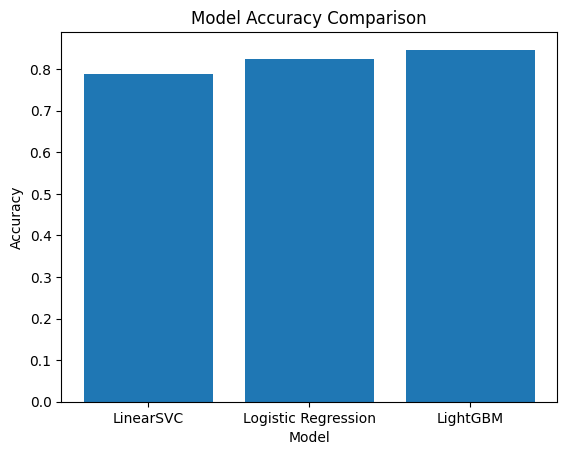

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

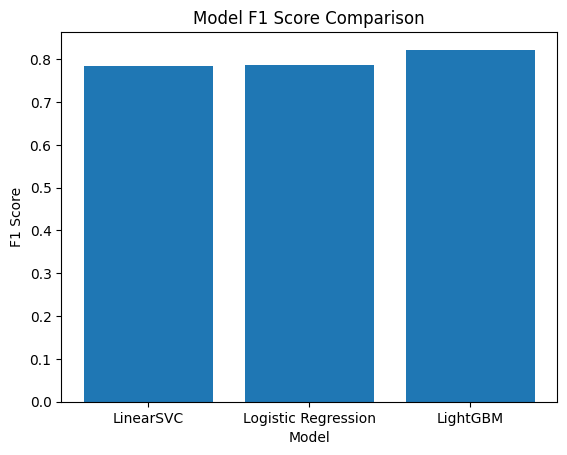

In [18]:
plt.figure()
plt.bar(results_df["Model"], results_df["F1 Score"])
plt.title("Model F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.show()

Conclusion - From my experiments, LightGBM performed best with an accuracy of 84.6% and F1 score of 82.2%, significantly outperforming linear models. While Logistic Regression provided a strong baseline due to its effectiveness on TF-IDF features, LightGBM captured non-linear relationships and feature interactions between textual and engineered features, leading to better overall performance, especially in terms of F1 score.

In [ ]:
#milestone 1 

In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.preprocessing import StandardScaler
# from sklearn.svm import LinearSVC
# from sklearn.metrics import accuracy_score
# from scipy.sparse import hstack


In [ ]:
# train_data = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
# test_data = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

# print(train_data.shape)
# print(test_data.shape)


In [ ]:
# train_data['upvote'].median()


In [ ]:
# train_data['if_2'].min()


In [ ]:
# train_data[['upvote', 'downvote', 'if_1', 'if_2']].max()


In [ ]:

# train_data['comment'] = train_data['comment'].fillna("")
# test_data['comment'] = test_data['comment'].fillna("")
# train_data['disability'] = train_data['disability'].astype(int)
# test_data['disability'] = test_data['disability'].astype(int)


In [ ]:
# num_cols = [
#     'upvote', 'downvote',
#     'if_1', 'if_2',
#     'emoticon_1', 'emoticon_2', 'emoticon_3',
#     'disability'
# ]


In [ ]:
#milestone 2

In [ ]:
# train_data['month'].value_counts()

In [ ]:
# train_data['total_emoticons'].max()

In [ ]:
# label_3_data = train_data[train_data['label'] == 3]

In [ ]:
# label_1_data = train_data[train_data['label'] == 1]

In [ ]:
#milestone 3 

In [ ]:
# import pandas as pd
# from sklearn.model_selection import train_test_split

# # Load
# df = pd.read_csv("train.csv")

# X = df.drop("label", axis=1)
# y = df["label"]

# # Split 80-20
# X_train, X_val, y_train, y_val = train_test_split(
#     X, y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )

# print(X_train.shape, X_val.shape)

In [ ]:
# for df_ in [X_train, X_val]:
#     df_["created_date"] = pd.to_datetime(df_["created_date"])
#     df_["day"] = df_["created_date"].dt.day
#     df_["month"] = df_["created_date"].dt.month
#     df_["year"] = df_["created_date"].dt.year

#     df_.drop("created_date", axis=1, inplace=True)

In [ ]:
# for df_ in [X_train, X_val]:
#     df_["is_weekend"] = (pd.to_datetime(df_["year"].astype(str) + "-" +
#                                        df_["month"].astype(str) + "-" +
#                                        df_["day"].astype(str)).dt.dayofweek >= 5).astype(int)

In [ ]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf = TfidfVectorizer(stop_words="english")

# X_train_text = tfidf.fit_transform(X_train["comment"])
# X_val_text = tfidf.transform(X_val["comment"])

In [ ]:
# from sklearn.preprocessing import OneHotEncoder

# cat_cols = ["religion", "gender", "race", "is_weekend"]

# ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

# X_train_cat = ohe.fit_transform(X_train[cat_cols])
# X_val_cat = ohe.transform(X_val[cat_cols])

In [ ]:
#milestone 4

In [ ]:

# import pandas as pd
# import numpy as np
# import re

# from sklearn.model_selection import train_test_split, RandomizedSearchCV
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.impute import SimpleImputer
# from sklearn.compose import ColumnTransformer
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.decomposition import TruncatedSVD

# from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
# from sklearn.neural_network import MLPClassifier
# from sklearn.metrics import f1_score, confusion_matrix

# from scipy.sparse import hstack
# df = pd.read_csv("train.csv")
# df["comment"] = df["comment"].fillna("")

# X = df.drop("label", axis=1)
# y = df["label"]

# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.4, random_state=2306, stratify=y
# )

# train_counts_A = y_train.value_counts().sort_index().values
# val_counts_A = y_val.value_counts().sort_index().values

# # Non-stratified
# X_train_ns, X_val_ns, y_train_ns, y_val_ns = train_test_split(
#     X, y, test_size=0.4, random_state=2306, stratify=None
# )

# val_counts_B = y_val_ns.value_counts().sort_index().values

# # Difference
# prop_A = val_counts_A / val_counts_A.sum()
# prop_B = val_counts_B / val_counts_B.sum()
# max_diff = np.max(np.abs(prop_A - prop_B))

# print("Q1:", round(max_diff, 4))

# # Drop created_date
# X_train = X_train.drop("created_date", axis=1)
# X_val = X_val.drop("created_date", axis=1)

# # Extract text
# text_x_train = X_train["comment"]
# text_x_test = X_val["comment"]

# X_train = X_train.drop("comment", axis=1)
# X_val = X_val.drop("comment", axis=1)

# # ColumnTransformer
# cat_cols = ["race", "religion", "gender", "disability"]
# num_cols = ["post_id", "emoticon_1", "emoticon_2", "emoticon_3",
#             "upvote", "downvote", "if_1", "if_2"]

# ct = ColumnTransformer([
#     ("cat", 
#      Pipeline([
#          ("imputer", SimpleImputer(strategy="most_frequent")),
#          ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
#      ]), cat_cols),

#     ("num",
#      Pipeline([
#          ("imputer", SimpleImputer(strategy="mean")),
#          ("scaler", StandardScaler())
#      ]), num_cols)
# ], remainder="passthrough")

# x_train_tabular = ct.fit_transform(X_train)
# x_test_tabular = ct.transform(X_val)

# def normalize_text(text):
#     text = re.sub(r'http\S+|www\S+', '', text)
#     text = re.sub(r'\s+', '  ', text).strip()
#     return text

# text_x_train_norm = text_x_train.apply(normalize_text)
# text_x_test_norm = text_x_test.apply(normalize_text)

# tfidf = TfidfVectorizer(stop_words="english", max_features=5000)

# tf_idf_train = tfidf.fit_transform(text_x_train_norm)
# tf_idf_test = tfidf.transform(text_x_test_norm)

# X_train_final = hstack([x_train_tabular, tf_idf_train])
# X_test_final = hstack([x_test_tabular, tf_idf_test])

# print("Q2:", round(X_train_final.sum(), 3))

# svd = TruncatedSVD(n_components=300, random_state=2306)

# X_train_reduced = svd.fit_transform(X_train_final)
# X_test_reduced = svd.transform(X_test_final)

# rf = RandomForestClassifier(random_state=2306)

# param_dist = {
#     "n_estimators": [50, 100, 200],
#     "max_depth": [5, 10, 15]
# }

# rs = RandomizedSearchCV(
#     rf,
#     param_dist,
#     n_iter=5,
#     cv=3,
#     random_state=2306,
#     n_jobs=-1
# )

# rs.fit(X_train_reduced, y_train)
# print("Q3:", rs.best_params_["n_estimators"])

# ada = AdaBoostClassifier(n_estimators=50, random_state=2306)
# ada.fit(X_train_reduced, y_train)

# var_error = np.var(ada.estimator_errors_)
# print("Q4:", round(var_error, 4))

# rf_fixed = RandomForestClassifier(
#     n_estimators=100, max_depth=10, random_state=2306
# )
# rf_fixed.fit(X_train_reduced, y_train)

# print("Q5:", np.argmax(rf_fixed.feature_importances_))
# # =========================
# N = X_train_reduced.shape[1]

# weights = (
#     N*128 +
#     128*64 +
#     64*32 +
#     32*4
# )


# mlp = MLPClassifier(
#     hidden_layer_sizes=(128,64,32),
#     activation="relu",
#     solver="adam",
#     max_iter=5,
#     batch_size=32,
#     random_state=2306
# )

# mlp.fit(X_train_reduced, y_train)
# print("Q7:", round(mlp.loss_, 4))
# mlp_A = MLPClassifier(hidden_layer_sizes=(100,), max_iter=5,
#                       alpha=0.0001, random_state=2306)

# mlp_B = MLPClassifier(hidden_layer_sizes=(100,), max_iter=5,
#                       alpha=1.0, random_state=2306)

# mlp_A.fit(X_train_reduced, y_train)
# mlp_B.fit(X_train_reduced, y_train)

# f1_A = f1_score(y_train, mlp_A.predict(X_train_reduced), average="macro")
# f1_B = f1_score(y_train, mlp_B.predict(X_train_reduced), average="macro")


# val_preds = mlp.predict(X_test_reduced)

# cm = confusion_matrix(y_val, val_preds)

# off_diag = cm.sum() - np.trace(cm)
# ratio = off_diag / cm.sum()

In [ ]:

# import pandas as pd
# import numpy as np

# from sklearn.model_selection import train_test_split, GridSearchCV
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.feature_extraction.text import TfidfVectorizer

# from sklearn.naive_bayes import MultinomialNB
# from sklearn.linear_model import LogisticRegression

# from sklearn.metrics import accuracy_score, classification_report

# df = pd.read_csv("train.csv")
# test_df = pd.read_csv("test.csv")

# y = df["label"]
# df = df.drop("label", axis=1)

# for d in [df, test_df]:
#     d["created_date"] = pd.to_datetime(d["created_date"])
#     d["year"] = d["created_date"].dt.year
#     d["month"] = d["created_date"].dt.month
#     d["hour"] = d["created_date"].dt.hour
#     d.drop("created_date", axis=1, inplace=True)

# for d in [df, test_df]:
#     # categorical
#     for col in ["race", "religion", "gender"]:
#         d[col] = d[col].fillna("Unknown")

#     # text
#     d["comment"] = d["comment"].fillna("")

#     # boolean
#     d["disability"] = d["disability"].astype(int)

# text_col = "comment"
# cat_cols = ["race", "religion", "gender"]

# preprocessor = ColumnTransformer(
#     transformers=[
#         ("text", TfidfVectorizer(stop_words="english", max_features=5000), text_col),
#         ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
#     ],
#     remainder="passthrough"
# )

# X = preprocessor.fit_transform(df)
# X_test = preprocessor.transform(test_df)
# X_train, X_val, y_train, y_val = train_test_split(
#     X, y,
#     test_size=0.2,
#     random_state=42
# )
# print("Q1:", 5000)

# print("Q2:", X_train.shape[1])
# print("Q3:", X_val.shape[1])
# nb = MultinomialNB()
# nb.fit(X_train, y_train)

# nb_preds = nb.predict(X_val)
# nb_acc = accuracy_score(y_val, nb_preds)

# print("Q4:", round(nb_acc, 3))

# report_nb = classification_report(y_val, nb_preds, output_dict=True)
# print("Q5:", round(report_nb["3"]["precision"], 2))

# lr = LogisticRegression(max_iter=500, random_state=42)
# lr.fit(X_train, y_train)

# lr_val_preds = lr.predict(X_val)
# lr_val_acc = accuracy_score(y_val, lr_val_preds)

# print("Q6:", round(lr_val_acc, 3))

# lr_train_preds = lr.predict(X_train)
# lr_train_acc = accuracy_score(y_train, lr_train_preds)

# print("Q7:", round(lr_train_acc, 3))
# report_lr = classification_report(y_val, lr_val_preds, output_dict=True)
# print("Q8:", round(report_lr["1"]["precision"], 2))
